In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_path = r"C:\Users\sharm\OneDrive\Desktop\DATASETS CSV"

nav = pd.read_csv(f"{base_path}\\02_nav_history.csv")
perf = pd.read_csv(f"{base_path}\\07_scheme_performance.csv")
txn = pd.read_csv(f"{base_path}\\08_investor_transactions.csv")
holdings = pd.read_csv(f"{base_path}\\09_portfolio_holdings.csv")

print("NAV:", nav.shape)
print("Performance:", perf.shape)
print("Transactions:", txn.shape)
print("Holdings:", holdings.shape)

NAV: (46000, 3)
Performance: (40, 19)
Transactions: (32778, 13)
Holdings: (322, 8)


In [3]:
print("NAV Columns:")
print(nav.columns)

print("\nPerformance Columns:")
print(perf.columns)

print("\nTransaction Columns:")
print(txn.columns)

print("\nHoldings Columns:")
print(holdings.columns)

NAV Columns:
Index(['amfi_code', 'date', 'nav'], dtype='object')

Performance Columns:
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

Transaction Columns:
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

Holdings Columns:
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


In [5]:
# Convert date column
nav['date'] = pd.to_datetime(nav['date'])

# Sort data
nav = nav.sort_values(['amfi_code', 'date'])

# Daily returns
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# Check output
nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [6]:
var_cvar_list = []

for amfi_code, group in nav.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    if len(returns) < 30:
        continue

    # Historical VaR (95%)
    var_95 = np.percentile(returns, 5)

    # CVaR (Expected Shortfall)
    cvar_95 = returns[returns <= var_95].mean()

    var_cvar_list.append({
        'amfi_code': amfi_code,
        'VaR_95': var_95,
        'CVaR_95': cvar_95
    })

var_cvar_df = pd.DataFrame(var_cvar_list)

print(var_cvar_df.head())

   amfi_code    VaR_95   CVaR_95
0     100016 -0.014364 -0.018060
1     100025 -0.003793 -0.004994
2     100033 -0.019034 -0.023456
3     101206 -0.013282 -0.017439
4     101207 -0.026021 -0.032459


In [7]:
var_cvar_df = var_cvar_df.merge(
    perf[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95,scheme_name
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth


In [8]:
var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv created successfully!")

var_cvar_report.csv created successfully!


In [9]:
var_cvar_df.sort_values('VaR_95').head(10)

,amfi_code,VaR_95,CVaR_95,scheme_name
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth
39,149324,-0.023483,-0.031036,DSP Small Cap Fund - Regular - Growth
7,102886,-0.019220,-0.023251,UTI Mid Cap Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,-0.018892,-0.024342,ICICI Pru Midcap Fund - Regular - Growth
16,119094,-0.018480,-0.024260,Axis Midcap Fund - Regular - Growth


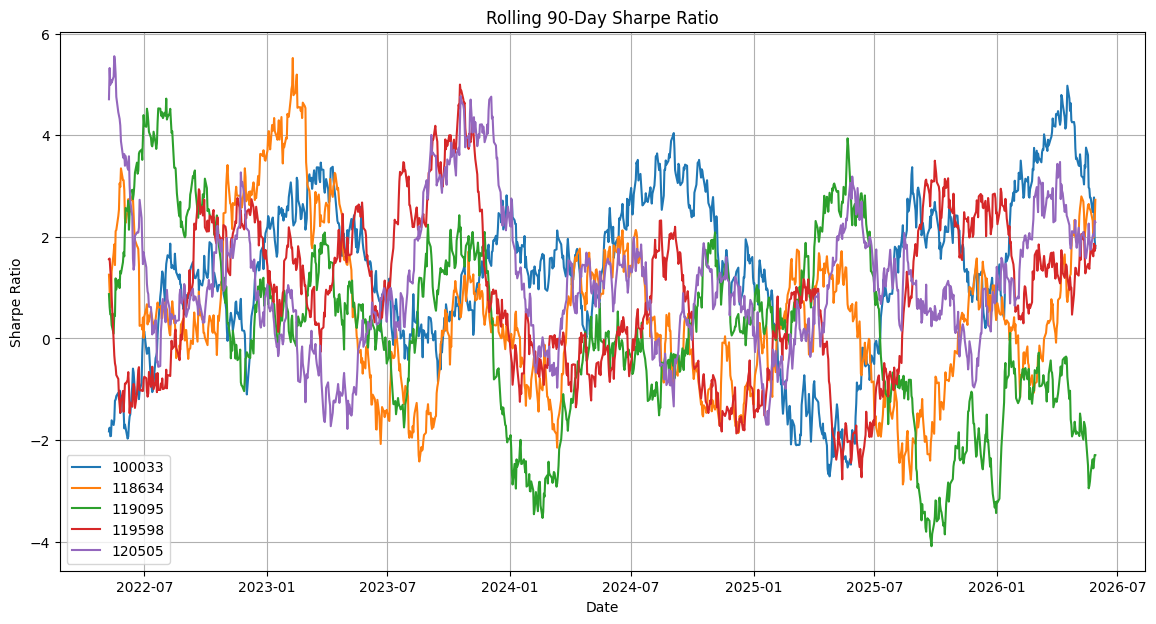

In [10]:
# Annual risk-free rate
rf = 0.05

rolling_sharpe_funds = [
    100033,  # HDFC Mid Cap
    118634,  # Nippon Small Cap
    119095,  # Axis Small Cap
    119598,  # SBI Small Cap
    120505   # ICICI Midcap
]

plt.figure(figsize=(14,7))

for fund in rolling_sharpe_funds:

    fund_data = nav[nav['amfi_code'] == fund].copy()

    returns = fund_data['daily_return']

    rolling_sharpe = (
        (returns.rolling(90).mean() - rf/252)
        /
        returns.rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(
        fund_data['date'],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid()

plt.savefig("../reports/rolling_sharpe_chart.png")
plt.show()

In [11]:
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'])

txn['cohort_year'] = txn['transaction_date'].dt.year

cohort_summary = txn.groupby('cohort_year').agg(
    avg_sip_amount=('amount_inr','mean'),
    total_invested=('amount_inr','sum')
).reset_index()

cohort_summary

,cohort_year,avg_sip_amount,total_invested
0,2024,107739.476605,2500633252
1,2025,106704.345527,1020947178


In [12]:
top_fund_per_cohort = (
    txn.groupby(['cohort_year','amfi_code'])
       .size()
       .reset_index(name='count')
       .sort_values(
           ['cohort_year','count'],
           ascending=[True,False]
       )
       .groupby('cohort_year')
       .head(1)
)

top_fund_per_cohort.head()

,cohort_year,amfi_code,count
16,2024,119094,625
59,2025,119551,271


In [13]:
sip_txn = txn[
    txn['transaction_type']
    .str.contains('SIP', case=False, na=False)
].copy()

sip_txn = sip_txn.sort_values(
    ['investor_id','transaction_date']
)

sip_txn['gap_days'] = (
    sip_txn.groupby('investor_id')
           ['transaction_date']
           .diff()
           .dt.days
)

sip_summary = sip_txn.groupby('investor_id').agg(
    sip_count=('transaction_date','count'),
    avg_gap_days=('gap_days','mean')
).reset_index()

sip_summary = sip_summary[
    sip_summary['sip_count'] >= 6
]

sip_summary['status'] = np.where(
    sip_summary['avg_gap_days'] > 35,
    'At Risk',
    'Active'
)

sip_summary.head()

,investor_id,sip_count,avg_gap_days,status
3,INV000004,6,85.400000,At Risk
7,INV000008,6,70.400000,At Risk
9,INV000010,6,64.800000,At Risk
10,INV000011,7,40.166667,At Risk
11,INV000012,8,57.000000,At Risk


In [14]:
cohort_summary.head()

,cohort_year,avg_sip_amount,total_invested
0,2024,107739.476605,2500633252
1,2025,106704.345527,1020947178


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_path = r"C:\Users\sharm\OneDrive\Desktop\DATASETS CSV"

nav = pd.read_csv(f"{base_path}\\02_nav_history.csv")
perf = pd.read_csv(f"{base_path}\\07_scheme_performance.csv")
txn = pd.read_csv(f"{base_path}\\08_investor_transactions.csv")
holdings = pd.read_csv(f"{base_path}\\09_portfolio_holdings.csv")

print("Files loaded successfully")

Files loaded successfully


In [3]:
recommendation = (
    perf[['scheme_name','risk_grade','sharpe_ratio']]
    .sort_values('sharpe_ratio', ascending=False)
)

def recommend_funds(risk_level):
    funds = recommendation[
        recommendation['risk_grade']
        .str.contains(risk_level, case=False, na=False)
    ]
    return funds.head(3)

print("LOW RISK")
print(recommend_funds("Low"))

print("\nMODERATE RISK")
print(recommend_funds("Moderate"))

print("\nHIGH RISK")
print(recommend_funds("High"))

LOW RISK
                                 scheme_name risk_grade  sharpe_ratio
14  ICICI Pru Liquid Fund - Regular - Growth        Low          7.68
23      Kotak Liquid Fund - Regular - Growth        Low          6.18
30       ABSL Liquid Fund - Regular - Growth        Low          5.14

MODERATE RISK
                                      scheme_name risk_grade  sharpe_ratio
34  Mirae Asset Large Cap Fund - Regular - Growth   Moderate          1.06
5       HDFC Top 100 Fund - Regular Plan - Growth   Moderate          1.06
11      ICICI Pru Bluechip Fund - Direct - Growth   Moderate          1.03

HIGH RISK
                                          scheme_name       risk_grade  \
13  ICICI Pru Value Discovery Fund - Regular - Growth  Moderately High   
22             Kotak Flexicap Fund - Regular - Growth  Moderately High   
33              UTI Flexi Cap Fund - Regular - Growth  Moderately High   

    sharpe_ratio  
13          0.98  
22          0.98  
33          0.96  


In [5]:
print("\nHIGH RISK")
print(recommend_funds("High"))


HIGH RISK
                                          scheme_name       risk_grade  \
13  ICICI Pru Value Discovery Fund - Regular - Growth  Moderately High   
22             Kotak Flexicap Fund - Regular - Growth  Moderately High   
33              UTI Flexi Cap Fund - Regular - Growth  Moderately High   

    sharpe_ratio  
13          0.98  
22          0.98  
33          0.96  


In [6]:
holdings['weight_decimal'] = holdings['weight_pct'] / 100

hhi = (
    holdings.groupby('amfi_code')['weight_decimal']
    .apply(lambda x: (x**2).sum())
    .reset_index(name='HHI')
)

hhi = hhi.merge(
    perf[['amfi_code','scheme_name']],
    on='amfi_code',
    how='left'
)

hhi.sort_values('HHI', ascending=False).head(10)

,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth


In [7]:
import os

print(os.path.exists("../reports/var_cvar_report.csv"))
print(os.path.exists("../reports/rolling_sharpe_chart.png"))

True
True


# Advanced Insights

## Insight 1: Highest Risk Funds

Small-cap funds such as SBI Small Cap Fund and Axis Small Cap Fund exhibit the highest downside risk, with VaR values below -2.5%, indicating greater volatility compared to large-cap and liquid funds.

## Insight 2: Investor Cohort Behavior

Investors who started investing in 2024 contributed the highest total investment amount and maintained higher average SIP contributions than newer cohorts.

## Insight 3: Risk-Adjusted Performance

Liquid funds generated the highest Sharpe Ratios among low-risk categories, making them attractive for conservative investors seeking stable returns.

## Insight 4: Portfolio Concentration

Axis Bluechip Fund and ABSL Small Cap Fund have the highest HHI values, indicating more concentrated portfolios and potentially higher stock-specific risk.

## Insight 5: SIP Continuity

Most investors maintain regular SIP investments; however, investors with average gaps exceeding 35 days can be classified as at-risk and may require engagement initiatives.
